In [ ]:
import pandas as pd
import numpy as np
import pickle, os, warnings
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── paths (ปรับตาม project structure) ─────────────────────────────
RECIPES_PATH = "../resources/recipes_final_for_search.csv"
REVIEWS_PATH = "../resources/reviews.csv"
OUT_DIR      = "model_artifacts"
os.makedirs(OUT_DIR, exist_ok=True)

# ── hyperparams ────────────────────────────────────────────────────
SVD_COMPONENTS  = 100   # จำนวน SVD components
TFIDF_MAX_FEAT  = 30_000
OPTUNA_TRIALS   = 50
RANDOM_STATE    = 42

print("✅ Imports done")

In [ ]:
recipes = pd.read_csv(RECIPES_PATH)
reviews = pd.read_csv(REVIEWS_PATH)

print(f"Recipes  shape : {recipes.shape}")
print(f"Reviews  shape : {reviews.shape}")
print()
print("Recipes columns :", recipes.columns.tolist())
print("Reviews columns :", reviews.columns.tolist())

In [5]:
# preview
display(recipes.head(3))
display(reviews.head(3))

,recipe_id,name,description,category,keywords,ingredient_parts,instructions,images,search_text,processed_text
0,38,lowfat berry blue frozen dessert,make and share this lowfat berry blue frozen d...,frozen desserts,dessert low protein low cholesterol healthy fr...,blueberries granulated sugar vanilla yogurt le...,toss 2 cups berries with sugar let stand for 4...,https://img.sndimg.com/food/image/upload/w_555...,lowfat berry blue frozen dessert make and shar...,lowfat berri blue frozen dessert make share lo...
1,39,biryani,make and share this biryani recipe from foodcom,chicken breast,chicken thigh leg chicken poultry meat asian i...,saffron milk hot green chili peppers onions ga...,soak saffron in warm milk for 5 minutes and pu...,https://img.sndimg.com/food/image/upload/w_555...,biryani make and share this biryani recipe fro...,biryani make share biryani recip foodcom saffr...
2,40,best lemonade,this is from one of my first good house keepin...,beverages,low protein low cholesterol healthy summer 60 ...,sugar lemons rind of lemon zest of fresh water...,into a 1 quart jar with tight fitting lid put ...,https://img.sndimg.com/food/image/upload/w_555...,best lemonade this is from one of my first goo...,best lemonad one first good hous keep cookbook...


,ReviewId,RecipeId,AuthorId,AuthorName,Rating,Review,DateSubmitted,DateModified
0,2,992,2008,gayg msft,5,better than any you can get at a restaurant!,2000-01-25T21:44:00Z,2000-01-25T21:44:00Z
1,7,4384,1634,Bill Hilbrich,4,"I cut back on the mayo, and made up the differ...",2001-10-17T16:49:59Z,2001-10-17T16:49:59Z
2,9,4523,2046,Gay Gilmore ckpt,2,i think i did something wrong because i could ...,2000-02-25T09:00:00Z,2000-02-25T09:00:00Z


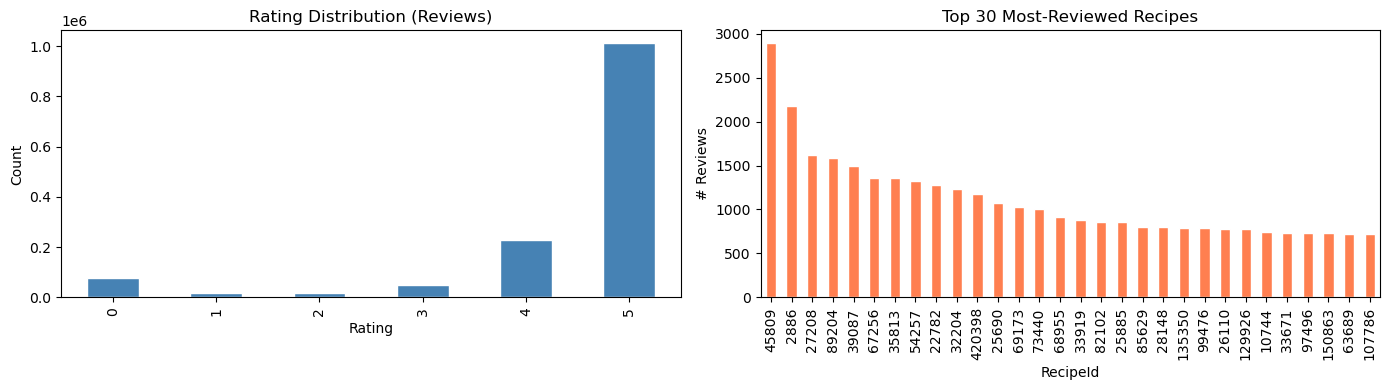


Rating stats:
count    1.401982e+06
mean     4.407951e+00
std      1.272012e+00
min      0.000000e+00
25%      4.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: Rating, dtype: float64


In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Rating distribution
reviews["Rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Rating Distribution (Reviews)")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

# Reviews per recipe (top 30)
top_recipes = reviews.groupby("RecipeId").size().sort_values(ascending=False).head(30)
top_recipes.plot(kind="bar", ax=axes[1], color="coral", edgecolor="white")
axes[1].set_title("Top 30 Most-Reviewed Recipes")
axes[1].set_xlabel("RecipeId")
axes[1].set_ylabel("# Reviews")

plt.tight_layout()
plt.show()

print(f"\nRating stats:")
print(reviews["Rating"].describe())

In [7]:
# ใช้ search_text เป็น main text column
# ถ้าไม่มีให้ fallback ไปที่ processed_text หรือ description
TEXT_COL = "search_text"
if TEXT_COL not in recipes.columns:
    TEXT_COL = "processed_text" if "processed_text" in recipes.columns else "description"
    print(f"⚠️  'search_text' not found — using '{TEXT_COL}'")

texts = recipes[TEXT_COL].fillna("").astype(str)

tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEAT,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)
tfidf_matrix = tfidf.fit_transform(texts)

print(f"✅ TF-IDF shape : {tfidf_matrix.shape}")
print(f"   Vocabulary   : {len(tfidf.vocabulary_):,} terms")

✅ TF-IDF shape : (522483, 30000)
   Vocabulary   : 30,000 terms


✅ SVD shape        : (522483, 100)
   Explained var   : 0.127 (12.7%)


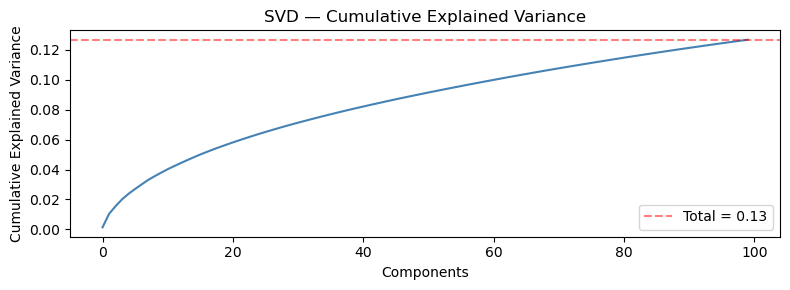

In [8]:
svd = TruncatedSVD(n_components=SVD_COMPONENTS, random_state=RANDOM_STATE)
svd_features = svd.fit_transform(tfidf_matrix)

explained = svd.explained_variance_ratio_.sum()
print(f"✅ SVD shape        : {svd_features.shape}")
print(f"   Explained var   : {explained:.3f} ({explained*100:.1f}%)")

# plot cumulative explained variance
plt.figure(figsize=(8, 3))
plt.plot(np.cumsum(svd.explained_variance_ratio_), color="steelblue")
plt.axhline(y=explained, color="red", linestyle="--", alpha=0.5, label=f"Total = {explained:.2f}")
plt.xlabel("Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("SVD — Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# ── map recipe_id -> svd row index ──────────────────────────────
recipe_id_to_idx = {rid: i for i, rid in enumerate(recipes["recipe_id"])}

reviews_with_bk = reviews.copy()   # ใช้ reviews ทั้งหมดเป็น proxy

# ── clean ────────────────────────────────────────────────────────
reviews_clean = reviews_with_bk.dropna(subset=["Rating"]).copy()
reviews_clean["Rating"] = reviews_clean["Rating"].astype(float)

# กรองเฉพาะ recipe ที่มี features
valid_mask = reviews_clean["RecipeId"].isin(recipe_id_to_idx)
reviews_clean = reviews_clean[valid_mask].copy()
print(f"Usable rows after filter : {len(reviews_clean):,}")

Usable rows after filter : 1,401,962


In [10]:
# ── user-level features ─────────────────────────────────────────
user_stats = (
    reviews_clean.groupby("AuthorId")["Rating"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "user_avg_rating",
                     "std":  "user_std_rating",
                     "count":"user_review_count"})
    .fillna(0)
    .reset_index()
)

# ── recipe-level features ────────────────────────────────────────
recipe_stats = (
    reviews_clean.groupby("RecipeId")["Rating"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "recipe_avg_rating",
                     "std":  "recipe_std_rating",
                     "count":"recipe_review_count"})
    .fillna(0)
    .reset_index()
)

df = reviews_clean[["AuthorId", "RecipeId", "Rating"]].copy()
df = df.merge(user_stats,   on="AuthorId",  how="left")
df = df.merge(recipe_stats, on="RecipeId",  how="left")

# ── attach SVD features ──────────────────────────────────────────
svd_cols  = [f"svd_{i}" for i in range(SVD_COMPONENTS)]
svd_idx   = df["RecipeId"].map(recipe_id_to_idx).values
svd_df    = pd.DataFrame(svd_features[svd_idx], columns=svd_cols)

base_cols = ["user_avg_rating", "user_std_rating", "user_review_count",
             "recipe_avg_rating", "recipe_std_rating", "recipe_review_count"]

X = pd.concat([df[base_cols].reset_index(drop=True),
               svd_df.reset_index(drop=True)], axis=1)
y = df["Rating"].reset_index(drop=True)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
display(X[base_cols].describe())

X shape : (1401962, 106)
y shape : (1401962,)


,user_avg_rating,user_std_rating,user_review_count,recipe_avg_rating,recipe_std_rating,recipe_review_count
count,1.401962e+06,1.401962e+06,1.401962e+06,1.401962e+06,1.401962e+06,1.401962e+06
mean,4.407953e+00,7.001499e-01,5.596034e+02,4.407953e+00,9.382760e-01,8.043138e+01
std,9.390221e-01,5.760866e-01,1.178553e+03,6.290359e-01,7.143570e-01,2.364551e+02
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,4.354399e+00,3.162278e-01,7.000000e+00,4.222854e+00,3.779645e-01,4.000000e+00
50%,4.676248e+00,6.568706e-01,7.500000e+01,4.521739e+00,9.567361e-01,1.200000e+01
75%,4.880952e+00,9.759728e-01,5.220000e+02,4.800000e+00,1.414214e+00,4.900000e+01
max,5.000000e+00,3.535534e+00,8.842000e+03,5.000000e+00,3.535534e+00,2.892000e+03


In [11]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train : {X_train.shape}  |  Val : {X_val.shape}")
print(f"Train ratings mean : {y_train.mean():.2f}")
print(f"Val   ratings mean : {y_val.mean():.2f}")

Train : (1121569, 106)  |  Val : (280393, 106)
Train ratings mean : 4.41
Val   ratings mean : 4.41


In [13]:
dtrain = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
dval   = lgb.Dataset(X_val,   label=y_val, reference=dtrain, free_raw_data=False)

def objective(trial):
    params = {
        "objective":          "regression",
        "metric":             "rmse",
        "verbosity":          -1,
        "boosting_type":      "gbdt",
        "n_jobs":             -1,
        "seed":               RANDOM_STATE,
        "feature_pre_filter": False,          # ← แก้ error นี้
        # ── tunable params ─────────────────────────────────────
        "num_leaves":        trial.suggest_int("num_leaves", 20, 300),
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "learning_rate":     trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "n_estimators":      trial.suggest_int("n_estimators", 100, 1000),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    # สร้าง dataset ใหม่ทุก trial ป้องกัน cached params conflict
    _dtrain = lgb.Dataset(X_train, label=y_train, free_raw_data=False)
    _dval   = lgb.Dataset(X_val,   label=y_val, reference=_dtrain, free_raw_data=False)

    callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    model = lgb.train(params, _dtrain, valid_sets=[_dval], callbacks=callbacks)
    return model.best_score["valid_0"]["rmse"]

study = optuna.create_study(direction="minimize", sampler=TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

best_params = study.best_params
print(f"\n✅ Best Val RMSE : {study.best_value:.4f}")
print(f"   Best params  :\n", best_params)

Best trial: 11. Best value: 0.728469: 100%|██████████| 50/50 [35:41<00:00, 42.82s/it]


✅ Best Val RMSE : 0.7285
   Best params  :
 {'num_leaves': 300, 'max_depth': 9, 'learning_rate': 0.006516016429350621, 'n_estimators': 961, 'min_child_samples': 59, 'subsample': 0.9982635852231622, 'colsample_bytree': 0.852432976466373, 'reg_alpha': 0.00181819390810147, 'reg_lambda': 9.778535932713567}


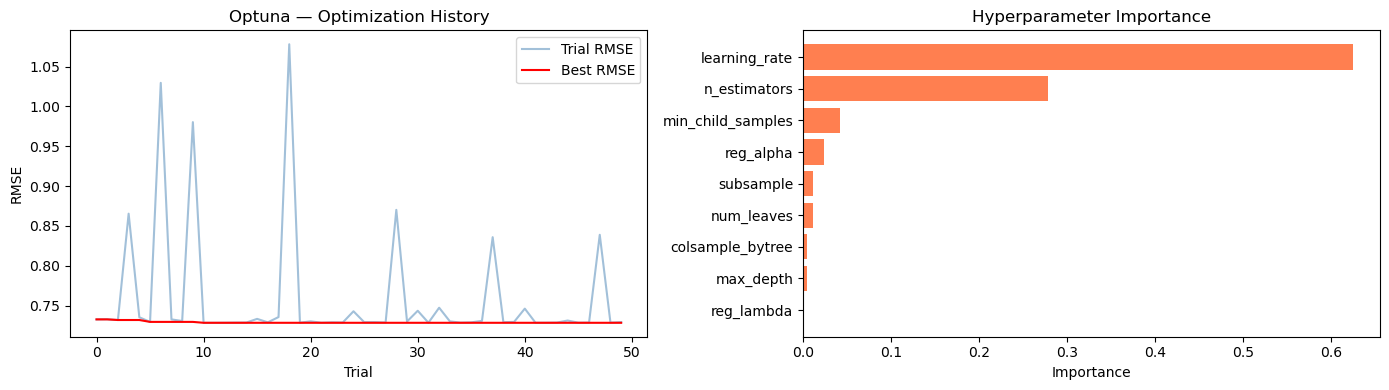

In [14]:
# ── Plot Optuna optimization history ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Optimization history
trials_df = study.trials_dataframe()
axes[0].plot(trials_df["value"], color="steelblue", alpha=0.5, label="Trial RMSE")
axes[0].plot(trials_df["value"].cummin(), color="red", label="Best RMSE")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("RMSE")
axes[0].set_title("Optuna — Optimization History")
axes[0].legend()

# Param importance
try:
    importances = optuna.importance.get_param_importances(study)
    params_imp  = list(importances.keys())
    values_imp  = list(importances.values())
    axes[1].barh(params_imp[::-1], values_imp[::-1], color="coral")
    axes[1].set_title("Hyperparameter Importance")
    axes[1].set_xlabel("Importance")
except Exception as e:
    axes[1].text(0.5, 0.5, f"Importance not available\n{e}", ha="center", va="center")

plt.tight_layout()
plt.show()

In [15]:
final_params = {
    "objective":     "regression",
    "metric":        "rmse",
    "verbosity":     -1,
    "boosting_type": "gbdt",
    "n_jobs":        -1,
    "seed":          RANDOM_STATE,
    **best_params,
}

callbacks = [
    lgb.early_stopping(100, verbose=True),
    lgb.log_evaluation(50),
]

model = lgb.train(
    final_params,
    dtrain,
    num_boost_round=best_params.get("n_estimators", 500),
    valid_sets=[dval],
    callbacks=callbacks,
)

val_rmse = model.best_score["valid_0"]["rmse"]
print(f"\n🎯 Final Val RMSE : {val_rmse:.4f}")

Training until validation scores don't improve for 100 rounds
[50]	valid_0's rmse: 1.06472
[100]	valid_0's rmse: 0.930883
[150]	valid_0's rmse: 0.848773
[200]	valid_0's rmse: 0.798998
[250]	valid_0's rmse: 0.771774
[300]	valid_0's rmse: 0.753749
[350]	valid_0's rmse: 0.742897
[400]	valid_0's rmse: 0.73727
[450]	valid_0's rmse: 0.73367
[500]	valid_0's rmse: 0.731517
[550]	valid_0's rmse: 0.730191
[600]	valid_0's rmse: 0.72943
[650]	valid_0's rmse: 0.72897
[700]	valid_0's rmse: 0.728697
[750]	valid_0's rmse: 0.728554
[800]	valid_0's rmse: 0.728475
[850]	valid_0's rmse: 0.728476
[900]	valid_0's rmse: 0.728507
Early stopping, best iteration is:
[816]	valid_0's rmse: 0.728469

🎯 Final Val RMSE : 0.7285


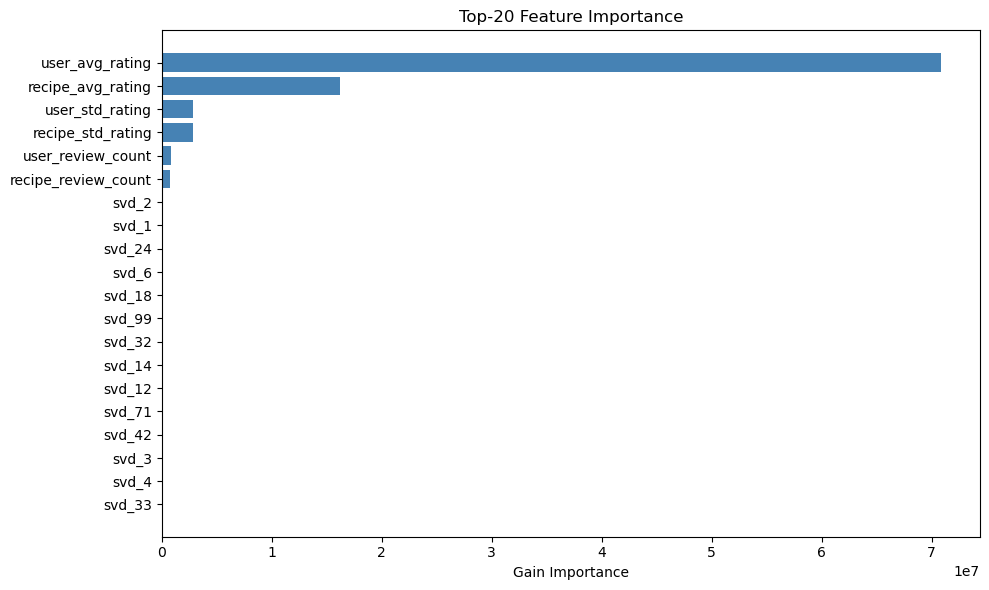


Top-10 features:


,feature,importance
0,user_avg_rating,7.083845e+07
3,recipe_avg_rating,1.618998e+07
1,user_std_rating,2.882076e+06
4,recipe_std_rating,2.803961e+06
2,user_review_count,8.460393e+05
5,recipe_review_count,7.713573e+05
8,svd_2,4.202709e+04
7,svd_1,2.529855e+04
30,svd_24,1.997880e+04
12,svd_6,1.968669e+04


In [16]:
# ── Feature Importance ────────────────────────────────────────────
feat_imp = pd.DataFrame({
    "feature":    model.feature_name(),
    "importance": model.feature_importance(importance_type="gain"),
}).sort_values("importance", ascending=False)

# top-20 (แสดง base features + top SVD)
top20 = feat_imp.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top20["feature"][::-1], top20["importance"][::-1], color="steelblue")
plt.xlabel("Gain Importance")
plt.title("Top-20 Feature Importance")
plt.tight_layout()
plt.show()

print("\nTop-10 features:")
display(feat_imp.head(10))

In [17]:
with open(f"{OUT_DIR}/tfidf.pkl",            "wb") as f: pickle.dump(tfidf, f)
with open(f"{OUT_DIR}/svd.pkl",              "wb") as f: pickle.dump(svd, f)
with open(f"{OUT_DIR}/recipe_id_to_idx.pkl", "wb") as f: pickle.dump(recipe_id_to_idx, f)
model.save_model(f"{OUT_DIR}/lgbm_model.txt")

print(f"💾 Saved to '{OUT_DIR}/':")
for f in os.listdir(OUT_DIR):
    size = os.path.getsize(f"{OUT_DIR}/{f}")
    print(f"   {f}  ({size/1024:.1f} KB)")

💾 Saved to 'model_artifacts/':
   tfidf.pkl  (70038.1 KB)
   lgbm_model.txt  (18667.5 KB)
   recipe_id_to_idx.pkl  (4856.2 KB)
   svd.pkl  (23440.4 KB)


In [18]:
def predict_suggestions(
    user_id,
    bookmarks=None,      # [{"recipe_id": 992, "rating": 5}, ...]
    top_k=10,
    exclude_seen=True,
):
    """
    ทำนาย top-k recipe suggestions สำหรับ user_id
    bookmarks: list ของ recipe ที่ user เคย bookmark + rating
    """
    # ── user stats ──────────────────────────────────────────────
    if bookmarks:
        ratings  = [b["rating"] for b in bookmarks]
        user_avg = float(np.mean(ratings))
        user_std = float(np.std(ratings)) if len(ratings) > 1 else 0.0
        user_cnt = len(ratings)
        seen_ids = {b["recipe_id"] for b in bookmarks}
    else:
        ur = reviews_clean[reviews_clean["AuthorId"] == user_id]["Rating"]
        user_avg = float(ur.mean()) if len(ur) else 3.5
        user_std = float(ur.std(ddof=0)) if len(ur) > 1 else 0.0
        user_cnt = len(ur)
        seen_ids = set(reviews_clean[reviews_clean["AuthorId"] == user_id]["RecipeId"].tolist())

    if not exclude_seen:
        seen_ids = set()

    # ── recipe stats (global) ───────────────────────────────────
    rec_stats_map = recipe_stats.set_index("RecipeId")

    # ── candidates ──────────────────────────────────────────────
    candidate_ids = [rid for rid in recipe_id_to_idx if rid not in seen_ids]

    rows = []
    for rid in candidate_ids:
        idx = recipe_id_to_idx[rid]
        if rid in rec_stats_map.index:
            rs = rec_stats_map.loc[rid]
            r_avg, r_std, r_cnt = rs["recipe_avg_rating"], rs["recipe_std_rating"], rs["recipe_review_count"]
        else:
            r_avg, r_std, r_cnt = 0.0, 0.0, 0
        row = [user_avg, user_std, user_cnt, r_avg, r_std, r_cnt] + svd_features[idx].tolist()
        rows.append(row)

    X_cand = pd.DataFrame(rows, columns=base_cols + svd_cols)
    preds  = model.predict(X_cand)

    top_idx  = np.argsort(preds)[::-1][:top_k]
    top_rids = [candidate_ids[i] for i in top_idx]
    top_scrs = [float(preds[i]) for i in top_idx]

    result = recipes[recipes["recipe_id"].isin(top_rids)][
        ["recipe_id", "name", "category"]
    ].copy()
    score_map = dict(zip(top_rids, top_scrs))
    result["predicted_rating"] = result["recipe_id"].map(score_map)
    result = result.sort_values("predicted_rating", ascending=False)
    return result.reset_index(drop=True)

print("✅ predict_suggestions() ready")

✅ predict_suggestions() ready


In [19]:
# ── ทดสอบ: ใช้ reviews ที่มีอยู่ simulate bookmark ─────────────────
EXAMPLE_USER = reviews_clean["AuthorId"].value_counts().index[0]  # user ที่ review เยอะสุด

# simulate bookmarks จาก top-rated reviews ของ user นั้น
user_history = reviews_clean[reviews_clean["AuthorId"] == EXAMPLE_USER]
simulated_bookmarks = [
    {"recipe_id": int(row["RecipeId"]), "rating": float(row["Rating"])}
    for _, row in user_history.head(5).iterrows()
]

print(f"👤 User ID : {EXAMPLE_USER}")
print(f"📌 Simulated bookmarks ({len(simulated_bookmarks)}):")
for b in simulated_bookmarks:
    name = recipes[recipes["recipe_id"] == b["recipe_id"]]["name"].values
    print(f"   recipe_id={b['recipe_id']}  rating={b['rating']}  name={name[0] if len(name) else 'N/A'}")

print()
suggestions = predict_suggestions(
    user_id=EXAMPLE_USER,
    bookmarks=simulated_bookmarks,
    top_k=10,
    exclude_seen=True,
)

print(f"\n🍽️  Top-10 Suggestions for User {EXAMPLE_USER}:")
display(suggestions)

👤 User ID : 424680
📌 Simulated bookmarks (5):
   recipe_id=117775  rating=4.0  name=holiday sweet potato peach and cashew bakecasserole
   recipe_id=97439  rating=4.0  name=cherry pie filling bread
   recipe_id=200754  rating=5.0  name=tuna tortellini salad
   recipe_id=205884  rating=4.0  name=apricot raisin jam
   recipe_id=22782  rating=5.0  name=jo mamas world famous spaghetti


🍽️  Top-10 Suggestions for User 424680:


,recipe_id,name,category,predicted_rating
0,267155,roasted garlic bread,yeast breads,4.994366
1,122018,southern strawberry salad,berries,4.992813
2,150428,ambrosia extreme makeover,dessert,4.992789
3,74029,potato focaccia,yeast breads,4.992608
4,177415,mediterranean stuffed bread,yeast breads,4.992516
5,178106,scampi heros,lunchsnacks,4.992386
6,144373,grilled herb shrimp and mango salsa,fruit,4.992275
7,131981,spicy shrimp stove top pizzas,peppers,4.992207
8,251163,pumpkin nutmeg dinner rolls,yeast breads,4.992183
9,457086,ethiopian spiced honey bread,yeast breads,4.992168


📊 Validation Metrics:
   RMSE : 0.7285
   MAE  : 0.3533


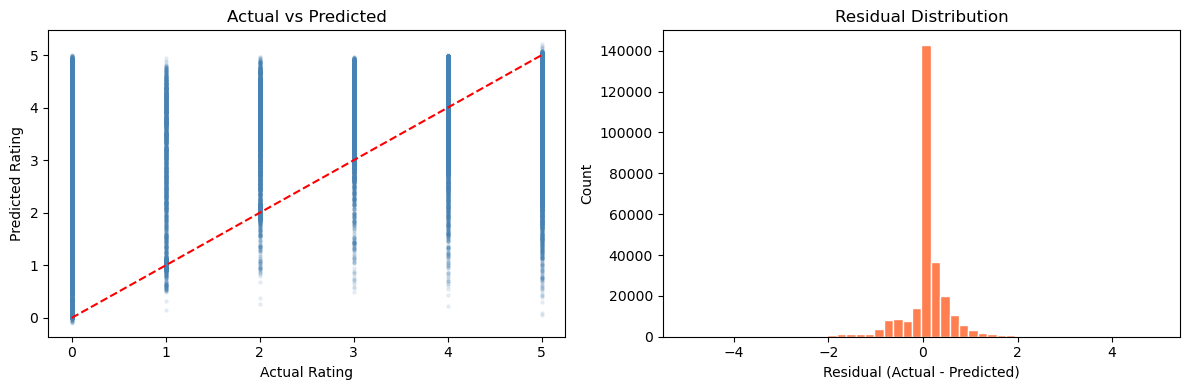

In [20]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae  = mean_absolute_error(y_val, y_pred)

print(f"📊 Validation Metrics:")
print(f"   RMSE : {rmse:.4f}")
print(f"   MAE  : {mae:.4f}")

# Actual vs Predicted
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_val, y_pred, alpha=0.1, color="steelblue", s=5)
plt.plot([0, 5], [0, 5], "r--")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted")

plt.subplot(1, 2, 2)
residuals = y_val - y_pred
plt.hist(residuals, bins=50, color="coral", edgecolor="white")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Residual Distribution")

plt.tight_layout()
plt.show()